# SFO 1-Hour and 12-Hour Flight Delay Baseline Model

In [1]:
#libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import os

/Users/justin/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/justin/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
print(os.getcwd())

/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/Baseline_Model


## Load data

In [3]:
# load .csv files into data frames
one_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_1h.csv")
twelve_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_12h.csv")

# let's add the 2-hour and 4-hour datasets to perform model work on
two_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_2h.csv")
four_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_4h.csv")

In [4]:
# check shape of both data frames
print("1hr df shape:", one_df.shape)
print("12hr df shape:", twelve_df.shape)

1hr df shape: (334086, 32)
12hr df shape: (346464, 32)


In [5]:
# check column names
print("one_df columns:\n", one_df.columns.tolist())

one_df columns:
 ['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code', 'destination_airport', 'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h', 'departure_delay_minutes']


In [6]:
# check column names
print("twelve_df columns:\n", twelve_df.columns.tolist())

twelve_df columns:
 ['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code', 'destination_airport', 'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h', 'departure_delay_minutes']


In [7]:
# lets check the date range for each df
print("1hr date range:", one_df['date'].min(), one_df['date'].max())
print("12hr date range:", twelve_df['date'].min(), twelve_df['date'].max())

1hr date range: 2022-01-01 2026-04-30
12hr date range: 2022-01-01 2026-04-30


In [8]:
# check for missing values in df
print("one_df missing value count:", one_df.isnull().sum())
print("twellve_df missing value count:", twelve_df.isnull().sum())

one_df missing value count: date                              0
scheduled_dep_dt                  0
actual_dep_dt                     0
carrier_code                      0
destination_airport               0
scheduled_elapsed_time_minutes    0
year                              0
month                             0
day_of_week                       0
is_weekend                        0
sched_dep_hour                    0
outcome                           0
days_until_holiday                0
days_from_holiday                 0
year_mfr                          0
model                             0
no_seats                          0
visibility                        0
ceiling_height                    0
wind_speed                        0
wind_direction                    0
temperature                       0
dew_point_temperature             0
relative_humidity                 0
altimeter                         0
aircraft_age                      0
week_num                          0


## Split the data into Train/Validation/Test

We will use a split as follows\
Train: 2022-01-01 to 2024-12-31\
Validate: 2025-01-01 to 2025-12-31\
Test: 2026-01-01 to 2026-04-03

In [9]:
# 1-hour data
one_train_df = one_df[
    (one_df['date'] >= "2022-01-01") &
    (one_df['date'] <= "2024-12-31")
]
one_val_df = one_df[
    (one_df['date'] >= "2025-01-01") &
    (one_df['date'] <= "2025-12-31")
]
one_test_df = one_df[
    (one_df['date'] >= "2026-01-01") &
    (one_df['date'] <= "2026-04-30")
]

In [10]:
print("1-hr. train shape:", one_train_df.shape)
print("1-hr. val shape:", one_val_df.shape)
print("1-hr. test shape:", one_test_df.shape)

1-hr. train shape: (236106, 32)
1-hr. val shape: (81325, 32)
1-hr. test shape: (16655, 32)


In [11]:
# 12-hour data
twelve_train_df = twelve_df[
    (twelve_df['date'] >= "2022-01-01") &
    (twelve_df['date'] <= "2024-12-31")
]
twelve_val_df = twelve_df[
    (twelve_df['date'] >= "2025-01-01") &
    (twelve_df['date'] <= "2025-12-31")
]
twelve_test_df = twelve_df[
    (twelve_df['date'] >= "2026-01-01") &
    (twelve_df['date'] <= "2026-04-30")
]

In [12]:
print("12-hour train shape:", twelve_train_df.shape)
print("12-hour val shape:", twelve_val_df.shape)
print("12-hour test shape:", twelve_test_df.shape)

12-hour train shape: (245694, 32)
12-hour val shape: (83399, 32)
12-hour test shape: (17371, 32)


## Feature selection (simple style) & X-y split

In [13]:
# numeric only feature selection
features = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h",
]

target = "departure_delay_minutes"

In [14]:
# separate train/val/test with features and target variables for X, y
## for one_df
one_X_train = one_train_df[features]
one_y_train = one_train_df[target]

one_X_val = one_val_df[features]
one_y_val = one_val_df[target]

one_X_test = one_test_df[features]
one_y_test = one_test_df[target]

## for twelve_df
twelve_X_train = twelve_train_df[features]
twelve_y_train = twelve_train_df[target]

twelve_X_val = twelve_val_df[features]
twelve_y_val = twelve_val_df[target]

twelve_X_test = twelve_test_df[features]
twelve_y_test = twelve_test_df[target]

## Scale features for optimal performance

In [15]:
# one hour transforms
# get scaler
one_scaler = StandardScaler()
one_scaler.fit(one_X_train)
# scale one
one_X_train_std = one_scaler.transform(one_X_train)
one_X_val_std = one_scaler.transform(one_X_val)
one_X_test_std = one_scaler.transform(one_X_test)

# twelve hour transforms
# get scaler
twelve_scaler = StandardScaler()
twelve_scaler.fit(twelve_X_train)
# scale twelve
twelve_X_train_std = twelve_scaler.transform(twelve_X_train)
twelve_X_val_std = twelve_scaler.transform(twelve_X_val)
twelve_X_test_std = twelve_scaler.transform(twelve_X_test)

In [16]:
print("1hr train mean for first 5:", one_X_train_std.mean(axis=0)[:5])
print("1hr train std for first 5: ", one_X_train_std.std(axis=0)[:5])
print("12hr train mean for first 5:", twelve_X_train_std.mean(axis=0)[:5])
print("12hr train std for first 5:", twelve_X_train_std.std(axis=0)[:5])

1hr train mean for first 5: [-4.47802085e-17  9.47992199e-15  1.54082438e-16 -1.92603047e-16
  9.72645389e-17]
1hr train std for first 5:  [1. 1. 1. 1. 1.]
12hr train mean for first 5: [-1.20537828e-16  1.45922494e-14 -1.33262551e-16 -1.58480638e-16
 -1.80459705e-17]
12hr train std for first 5: [1. 1. 1. 1. 1.]


## Baseline Linear Regression Model

In [17]:
# build regression model with single dense layer
def build_model(num_features, learning_rate):
    tf.keras.backend.clear_session() # reset model
    tf.random.set_seed(0) # reproducible seed

    # build the model
    model = tf.keras.Sequential([ 
        tf.keras.Input(shape=(num_features,)), # use features for input, define how many
        tf.keras.layers.Dense(units=1, use_bias=True) # output single number
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) # use the Adam optimizer

    # use Adam for weight optimization, MSE for prediction error
    model.compile( 
        optimizer=optimizer,
        loss="mse", # compute loss as mean squared error
        metrics=["mae"] # convert MSE back into minutes
    )

    return model

In [18]:
# build model for both 1-hr and 12-hr data
one_model = build_model(one_X_train_std.shape[1], learning_rate=0.001)
twelve_model = build_model(twelve_X_train_std.shape[1], learning_rate=0.001)

2026-07-15 19:36:25.745199: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-15 19:36:25.745584: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-15 19:36:25.745589: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-07-15 19:36:25.745766: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-15 19:36:25.745775: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [19]:
# confirmn model
one_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Models (1-hour and 12-hour)

In [20]:
# train models
one_history = one_model.fit(
    one_X_train_std,
    one_y_train,
    validation_data=(one_X_val_std, one_y_val),
    epochs=30,
    batch_size=256
)

Epoch 1/30
  1/923 ━━━━━━━━━━━━━━━━━━━━ 4:32 296ms/step - loss: 1297.0027 - mae: 15.0742

2026-07-15 19:36:26.099601: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-07-15 19:36:26.102098: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1684.1639 - mae: 16.2936 - val_loss: 1729.2389 - val_mae: 17.1713
Epoch 2/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1653.0046 - mae: 16.3990 - val_loss: 1698.9673 - val_mae: 17.7759
Epoch 3/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1632.0386 - mae: 16.5926 - val_loss: 1682.3961 - val_mae: 18.3183
Epoch 4/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1615.8635 - mae: 16.7941 - val_loss: 1672.7997 - val_mae: 18.8072
Epoch 5/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.5679 - mae: 17.0032 - val_loss: 1667.1414 - val_mae: 19.2605
Epoch 6/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1591.3890 - mae: 17.2245 - val_loss: 1663.9724 - val_mae: 19.6894
Epoch 7/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1581.9763 - mae: 17.4598 - val_loss: 1662.5476 - val_mae: 20.1006
Epoch 8/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1574.1317 - mae: 17.7079 - val_loss: 1662.4447 - val_mae: 20.4965
Epo

1-hour results: 

predictions on 1-hour training are off by about 19.65 minutes,   
while applied to the validation data off by about 22.78 minutes

In [21]:
# twelve hour train
twelve_history = twelve_model.fit(
    twelve_X_train_std, twelve_y_train,
    validation_data=(twelve_X_val_std, twelve_y_val),
    epochs=30,
    batch_size=256
)

Epoch 1/30
 16/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1944.8613 - mae: 15.6380    

2026-07-15 19:38:17.500380: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1695.7758 - mae: 16.4380 - val_loss: 1691.3618 - val_mae: 17.4058
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1669.9603 - mae: 16.5301 - val_loss: 1669.6455 - val_mae: 18.0084
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1650.8710 - mae: 16.7173 - val_loss: 1656.3625 - val_mae: 18.5845
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1635.5120 - mae: 16.9376 - val_loss: 1648.2667 - val_mae: 19.1305
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1622.7109 - mae: 17.1791 - val_loss: 1643.6523 - val_mae: 19.6504
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1611.9443 - mae: 17.4385 - val_loss: 1641.5424 - val_mae: 20.1474
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.9392 - mae: 17.7128 - val_loss: 1641.3282 - val_mae: 20.6238
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1595.5260 - mae: 17.9977 - val_loss: 1642.5831 - val_mae: 21.0787
Epo

Results for 12-hour:  
Training is off about 20.05 minutes,  
Validation is off by 23.69 minutes.
*validation lowest at epoch 6 for 19.53 minutes and training of 17.16 minutes

### Train and Validation Performance Plots

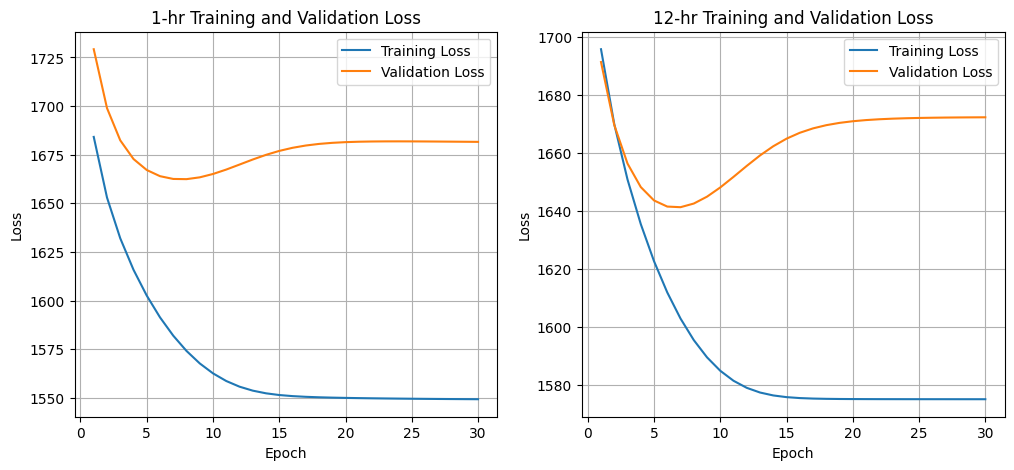

In [22]:
# get axis parameters
num_epochs = len(one_history.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# plot one_hour
plt.subplot(1,2,1)
plt.plot(epochs, one_history.history["loss"], label="Training Loss")
plt.plot(epochs, one_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1-hr Training and Validation Loss")
plt.legend()
plt.grid()

# plot twelve hour model
plt.subplot(1,2,2)
plt.plot(epochs, twelve_history.history["loss"], label="Training Loss")
plt.plot(epochs, twelve_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("12-hr Training and Validation Loss")
plt.legend()
plt.grid()

### Evaluate Baseline Model Results

In [23]:
# run trained model on dataset and evaluate performance
one_test_loss, one_test_mae = one_model.evaluate(one_X_test_std, one_y_test)
twelve_test_loss, twelve_test_mae = twelve_model.evaluate(twelve_X_test_std, twelve_y_test)
# print out performance results
print(f"1-hr test loss MSE: {one_test_loss:.4f}, test MAE: {one_test_mae}")
print(f"12-hr test loss MSE: {twelve_test_loss:.4f}, test MAE: {twelve_test_mae}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1563.8066 - mae: 24.1851
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1601.4827 - mae: 25.2504
1-hr test loss MSE: 1563.8066, test MAE: 24.185056686401367
12-hr test loss MSE: 1601.4827, test MAE: 25.25038719177246


## Classification Model

### 1-hour model

In [24]:
cl_target = "outcome" # use outcome to predict 9 categories of delay

# split data into train, val, and test
# use same feature set as regression model
one_X_train_cl = one_train_df[features]
one_y_train_cl = one_train_df[cl_target]
one_X_val_cl = one_val_df[features]
one_y_val_cl = one_val_df[cl_target]
one_X_test_cl = one_test_df[features]
one_y_test_cl = one_test_df[cl_target]

# scale the train, val, test data
one_X_train_cl_std = one_scaler.transform(one_X_train_cl)
one_X_val_cl_std = one_scaler.transform(one_X_val_cl)
one_X_test_cl_std = one_scaler.transform(one_X_test_cl)

### build classfication model

In [25]:
def build_classifier(num_features, num_classes, learning_rate): # function to use for classification model
    tf.keras.backend.clear_session() # start fresh
    tf.random.set_seed(0)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(num_features,)),
        tf.keras.layers.Dense(units=num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### train classification model

In [26]:
one_classifier = build_classifier(
    num_features= one_X_train_cl_std.shape[1], 
    num_classes= 9, 
    learning_rate=0.01)

one_cl_history = one_classifier.fit(
    one_X_train_cl_std,
    one_y_train_cl,
    validation_data=(one_X_val_cl_std, one_y_val_cl),
    epochs=20,
    batch_size=256
)

Epoch 1/20
  1/923 ━━━━━━━━━━━━━━━━━━━━ 3:35 234ms/step - accuracy: 0.1328 - loss: 2.8589

2026-07-15 19:40:14.675943: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


923/923 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5874 - loss: 1.0300 - val_accuracy: 0.6303 - val_loss: 0.8973
Epoch 2/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6048 - loss: 0.9030 - val_accuracy: 0.6317 - val_loss: 0.8941
Epoch 3/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6320 - val_loss: 0.8937
Epoch 4/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9020 - val_accuracy: 0.6320 - val_loss: 0.8937
Epoch 5/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6320 - val_loss: 0.8938
Epoch 6/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6049 - loss: 0.9021 - val_accuracy: 0.6319 - val_loss: 0.8938
Epoch 7/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6318 - val_loss: 0.8939
Epoch 8/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6317 - val_

### 12-hour classification model

In [27]:
# split data into train, val, and test
# use same feature set as regression model
twelve_X_train_cl = twelve_train_df[features]
twelve_y_train_cl = twelve_train_df[cl_target]
twelve_X_val_cl = twelve_val_df[features]
twelve_y_val_cl = twelve_val_df[cl_target]
twelve_X_test_cl = twelve_test_df[features]
twelve_y_test_cl = twelve_test_df[cl_target]

# scale the train, val, test data
twelve_X_train_cl_std = twelve_scaler.transform(twelve_X_train_cl)
twelve_X_val_cl_std = twelve_scaler.transform(twelve_X_val_cl)
twelve_X_test_cl_std = twelve_scaler.transform(twelve_X_test_cl)

In [28]:
twelve_classifier = build_classifier(
    num_features=twelve_X_train_cl_std.shape[1], 
    num_classes=9, 
    learning_rate=0.01)

twelve_cl_history = twelve_classifier.fit(
    twelve_X_train_cl_std, twelve_y_train_cl,
    validation_data=(twelve_X_val_cl_std, twelve_y_val_cl),
    epochs=20, batch_size=256
)

Epoch 1/20
  1/960 ━━━━━━━━━━━━━━━━━━━━ 3:25 214ms/step - accuracy: 0.1055 - loss: 2.7488

2026-07-15 19:41:39.283533: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5806 - loss: 1.0352 - val_accuracy: 0.6295 - val_loss: 0.9129
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5987 - loss: 0.9158 - val_accuracy: 0.6296 - val_loss: 0.9109
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5987 - loss: 0.9152 - val_accuracy: 0.6295 - val_loss: 0.9110
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5986 - loss: 0.9152 - val_accuracy: 0.6293 - val_loss: 0.9112
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5985 - loss: 0.9152 - val_accuracy: 0.6292 - val_loss: 0.9113
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5985 - loss: 0.9152 - val_accuracy: 0.6291 - val_loss: 0.9113
Epoch 7/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6291 - val_loss: 0.9114
Epoch 8/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6291 - val_

In [29]:
# evaluate both models
one_test_loss, one_test_acc = one_classifier.evaluate(one_X_test_cl_std, one_y_test_cl)
twelve_test_loss, twelve_test_acc = twelve_classifier.evaluate(twelve_X_test_cl_std, twelve_y_test_cl)

print(f"1hr  Test Loss: {one_test_loss:.4f} | Test Accuracy: {one_test_acc:.4f}")
print(f"12hr Test Loss: {twelve_test_loss:.4f} | Test Accuracy: {twelve_test_acc:.4f}")

 28/521 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5235 - loss: 1.1071

2026-07-15 19:43:07.816163: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6130 - loss: 0.9219
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5943 - loss: 0.9668
1hr  Test Loss: 0.9219 | Test Accuracy: 0.6130
12hr Test Loss: 0.9668 | Test Accuracy: 0.5943


Classification results:  
1-hr: test loss = 0.92, test accuracy: 0.61  
12-hr: test loss = 0.96, test accuracy: 0.59

The 1 hour model has a lower loss of 0.9219 vs. 0.9668, meaning the 1-hr model is more confident in its predictions.
The 1-hour model also has a better accuracy predicting delays, at 61.30% vs. the 12-hour 59.43%

# Repeat for 2-hour and 4-hour datasets

In [30]:
# check shape of new df
print("2hr data shape:", two_df.shape)
print("4hr data shape:", four_df.shape)

2hr data shape: (335918, 32)
4hr data shape: (339996, 32)


In [31]:
# check the date range of these new dfs
print("2hr date range:", two_df['date'].min(), two_df["date"].max())
print("4hr date range:", four_df['date'].min(), four_df["date"].max())

2hr date range: 2022-01-01 2026-04-30
4hr date range: 2022-01-01 2026-04-30


## split the df into train/val/test

In [32]:
# 2-hour data
two_train_df = two_df[
    (two_df['date'] >= "2022-01-01") &
    (two_df['date'] <= "2024-12-31")
]
two_val_df = two_df[
    (two_df['date'] >= "2025-01-01") &
    (two_df['date'] <= "2025-12-31")
]
two_test_df = two_df[
    (two_df['date'] >= "2026-01-01") &
    (two_df['date'] <= "2026-04-30")
]

In [33]:
# 4-hour data
four_train_df = four_df[
    (four_df['date'] >= "2022-01-01") &
    (four_df['date'] <= "2024-12-31")
]
four_val_df = four_df[
    (four_df['date'] >= "2025-01-01") &
    (four_df['date'] <= "2025-12-31")
]
four_test_df = four_df[
    (four_df['date'] >= "2026-01-01") &
    (four_df['date'] <= "2026-04-30")
]

In [34]:
# validate the 2-hour split
print("2-hr. train shape:", two_train_df.shape)
print("2-hr. val shape:", two_val_df.shape)
print("2-hr. test shape:", two_test_df.shape)

2-hr. train shape: (236894, 32)
2-hr. val shape: (82202, 32)
2-hr. test shape: (16822, 32)


In [35]:
# validate the 4-hours split
print("4-hr. train shape:", four_train_df.shape)
print("4-hr. val shape:", four_val_df.shape)
print("4-hr. test shape:", four_test_df.shape)

4-hr. train shape: (240324, 32)
4-hr. val shape: (82785, 32)
4-hr. test shape: (16887, 32)


## Build regression model for 2-hour and 4-hour

In [36]:
# 2-hour train/val/test
two_X_train = two_train_df[features]
two_y_train = two_train_df[target]
two_X_val = two_val_df[features]
two_y_val = two_val_df[target]
two_X_test = two_test_df[features]
two_y_test = two_test_df[target]

# 4-hour data train/val/test
four_X_train = four_train_df[features]
four_y_train = four_train_df[target]
four_X_val = four_val_df[features]
four_y_val = four_val_df[target]
four_X_test = four_test_df[features]
four_y_test = four_test_df[target]

### scale the model

In [37]:
# get scaler for 2-hour
two_scaler = StandardScaler()
two_scaler.fit(two_X_train)

# scale the train, val, test data
two_X_train_std = two_scaler.transform(two_X_train)
two_X_val_std = two_scaler.transform(two_X_val)
two_X_test_std = two_scaler.transform(two_X_test)

# get scaler for 4-hour
four_scaler = StandardScaler()
four_scaler.fit(four_X_train)

# scale the train, val, test data
four_X_train_std = four_scaler.transform(four_X_train)
four_X_val_std = four_scaler.transform(four_X_val)
four_X_test_std = four_scaler.transform(four_X_test)

### build models

In [38]:
# two hour model
two_model = build_model(num_features=two_X_train_std.shape[1], learning_rate=0.001)
two_history = two_model.fit(
    two_X_train_std, two_y_train,
    validation_data=(two_X_val_std, two_y_val),
    epochs=30, batch_size=256
)

Epoch 1/30
 15/926 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1417.7360 - mae: 15.7163    

2026-07-15 19:44:41.321915: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1694.4452 - mae: 16.4167 - val_loss: 1719.2836 - val_mae: 17.0488
Epoch 2/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1664.1528 - mae: 16.4646 - val_loss: 1685.7698 - val_mae: 17.6107
Epoch 3/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1643.1284 - mae: 16.6185 - val_loss: 1666.9318 - val_mae: 18.1761
Epoch 4/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1626.8567 - mae: 16.8081 - val_loss: 1656.0757 - val_mae: 18.7182
Epoch 5/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1613.6200 - mae: 17.0203 - val_loss: 1649.9766 - val_mae: 19.2295
Epoch 6/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.6411 - mae: 17.2512 - val_loss: 1646.9331 - val_mae: 19.7140
Epoch 7/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1593.5107 - mae: 17.4976 - val_loss: 1645.9855 - val_mae: 20.1743
Epoch 8/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1585.9846 - mae: 17.7557 - val_loss: 1646.5522 - val_mae: 20.6116
Epo

In [39]:
# four hour model
four_model = build_model(num_features=four_X_train_std.shape[1], learning_rate=0.001)
four_history = four_model.fit(
    four_X_train_std, four_y_train,
    validation_data=(four_X_val_std, four_y_val),
    epochs=30, batch_size=256
)

Epoch 1/30
 16/939 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2199.8993 - mae: 17.3786    

2026-07-15 19:47:23.389536: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1697.5826 - mae: 16.4735 - val_loss: 1716.4081 - val_mae: 17.0495
Epoch 2/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1661.9175 - mae: 16.3903 - val_loss: 1681.6217 - val_mae: 17.6841
Epoch 3/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1639.5760 - mae: 16.5496 - val_loss: 1663.0375 - val_mae: 18.2955
Epoch 4/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1622.8185 - mae: 16.7513 - val_loss: 1652.5593 - val_mae: 18.8551
Epoch 5/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1609.2981 - mae: 16.9713 - val_loss: 1646.7760 - val_mae: 19.3738
Epoch 6/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1598.1567 - mae: 17.2090 - val_loss: 1644.0209 - val_mae: 19.8615
Epoch 7/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1588.9684 - mae: 17.4632 - val_loss: 1643.3690 - val_mae: 20.3232
Epoch 8/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1581.4656 - mae: 17.7289 - val_loss: 1644.2422 - val_mae: 20.7615
Epo

### baseline model comparison

In [47]:
# how do all of our models compare
one_test_loss, one_test_mae = one_model.evaluate(one_X_test_std, one_y_test)
twelve_test_loss, twelve_test_mae = twelve_model.evaluate(twelve_X_test_std, twelve_y_test)
two_test_loss, two_test_mae = two_model.evaluate(two_X_test_std, two_y_test)
four_test_loss, four_test_mae = four_model.evaluate(four_X_test_std, four_y_test)

print(f"1-hr  Test MAE: {one_test_mae:.3f}")
print(f"2-hr  Test MAE: {two_test_mae:.3f}")
print(f"4-hr  Test MAE: {four_test_mae:.3f}")
print(f"12-hr Test MAE: {twelve_test_mae:.3f}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1563.8066 - mae: 24.1851
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1601.4827 - mae: 25.2504
526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1497.1378 - mae: 24.6680
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1540.1444 - mae: 24.6849
1-hr  Test MAE: 24.185
2-hr  Test MAE: 24.668
4-hr  Test MAE: 24.685
12-hr Test MAE: 25.250


# classification models 2-hour and 4-hour

In [41]:
# split data into train, val, and test
# use same feature set as regression model
two_X_train_cl = two_train_df[features]
two_y_train_cl = two_train_df[cl_target]
two_X_val_cl = two_val_df[features]
two_y_val_cl = two_val_df[cl_target]
two_X_test_cl = two_test_df[features]
two_y_test_cl = two_test_df[cl_target]

In [42]:
# four hour data
four_X_train_cl = four_train_df[features]
four_y_train_cl = four_train_df[cl_target]
four_X_val_cl = four_val_df[features]
four_y_val_cl = four_val_df[cl_target]
four_X_test_cl = four_test_df[features]
four_y_test_cl = four_test_df[cl_target]

In [43]:
# scale the train, val, test data
two_X_train_cl_std = two_scaler.transform(two_X_train_cl)
two_X_val_cl_std = two_scaler.transform(two_X_val_cl)
two_X_test_cl_std = two_scaler.transform(two_X_test_cl)

four_X_train_cl_std = four_scaler.transform(four_X_train_cl)
four_X_val_cl_std = four_scaler.transform(four_X_val_cl)
four_X_test_cl_std = four_scaler.transform(four_X_test_cl)

In [44]:
# build two classifier
two_classifier = build_classifier(num_features=two_X_train_cl_std.shape[1], num_classes=9, learning_rate=0.01)
# train the classifier 
two_cl_history = two_classifier.fit(
    two_X_train_cl_std, two_y_train_cl,
    validation_data=(two_X_val_cl_std, two_y_val_cl),
    epochs=20, batch_size=256
)
# build four classifier
four_classifier = build_classifier(num_features=four_X_train_cl_std.shape[1], num_classes=9, learning_rate=0.01)
# trian four classifier
four_cl_history = four_classifier.fit(
    four_X_train_cl_std, four_y_train_cl,
    validation_data=(four_X_val_cl_std, four_y_val_cl),
    epochs=20, batch_size=256
)

Epoch 1/20
 15/926 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1338 - loss: 2.6949    

2026-07-15 19:55:13.935314: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


926/926 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5813 - loss: 1.0331 - val_accuracy: 0.5711 - val_loss: 0.9296
Epoch 2/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9051 - val_accuracy: 0.5700 - val_loss: 0.9269
Epoch 3/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5982 - loss: 0.9043 - val_accuracy: 0.5691 - val_loss: 0.9273
Epoch 4/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9043 - val_accuracy: 0.5681 - val_loss: 0.9278
Epoch 5/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9043 - val_accuracy: 0.5675 - val_loss: 0.9281
Epoch 6/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5983 - loss: 0.9044 - val_accuracy: 0.5671 - val_loss: 0.9282
Epoch 7/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9044 - val_accuracy: 0.5670 - val_loss: 0.9282
Epoch 8/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9044 - val_accuracy: 0.5669 - val_

2026-07-15 19:56:38.697996: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


939/939 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5826 - loss: 1.0270 - val_accuracy: 0.6161 - val_loss: 0.8995
Epoch 2/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5997 - loss: 0.9032 - val_accuracy: 0.6177 - val_loss: 0.8964
Epoch 3/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5996 - loss: 0.9024 - val_accuracy: 0.6187 - val_loss: 0.8958
Epoch 4/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5997 - loss: 0.9024 - val_accuracy: 0.6194 - val_loss: 0.8954
Epoch 5/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5998 - loss: 0.9024 - val_accuracy: 0.6197 - val_loss: 0.8952
Epoch 6/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5998 - loss: 0.9025 - val_accuracy: 0.6199 - val_loss: 0.8952
Epoch 7/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5998 - loss: 0.9025 - val_accuracy: 0.6200 - val_loss: 0.8951
Epoch 8/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5998 - loss: 0.9025 - val_accuracy: 0.6201 - val_

In [48]:
# let's compare the models
one_test_loss_cl, one_test_acc_cl = one_classifier.evaluate(one_X_test_cl_std, one_y_test_cl)
twelve_test_loss_cl, twelve_test_acc_cl = twelve_classifier.evaluate(twelve_X_test_cl_std, twelve_y_test_cl)
two_test_loss_cl, two_test_acc_cl = two_classifier.evaluate(two_X_test_cl_std, two_y_test_cl)
four_test_loss_cl, four_test_acc_cl = four_classifier.evaluate(four_X_test_cl_std, four_y_test_cl)

print(f"1-hr  Test Accuracy: {one_test_acc_cl:.4f}")
print(f"2-hr  Test Accuracy: {two_test_acc_cl:.4f}")
print(f"4-hr  Test Accuracy: {four_test_acc_cl:.4f}")
print(f"12-hr Test Accuracy: {twelve_test_acc_cl:.4f}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6130 - loss: 0.9219
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5943 - loss: 0.9668
526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5272 - loss: 0.9862
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5938 - loss: 0.9272
1-hr  Test Accuracy: 0.6130
2-hr  Test Accuracy: 0.5272
4-hr  Test Accuracy: 0.5938
12-hr Test Accuracy: 0.5943


### loss and accuracy plots for 2-hr and 4-hr regression

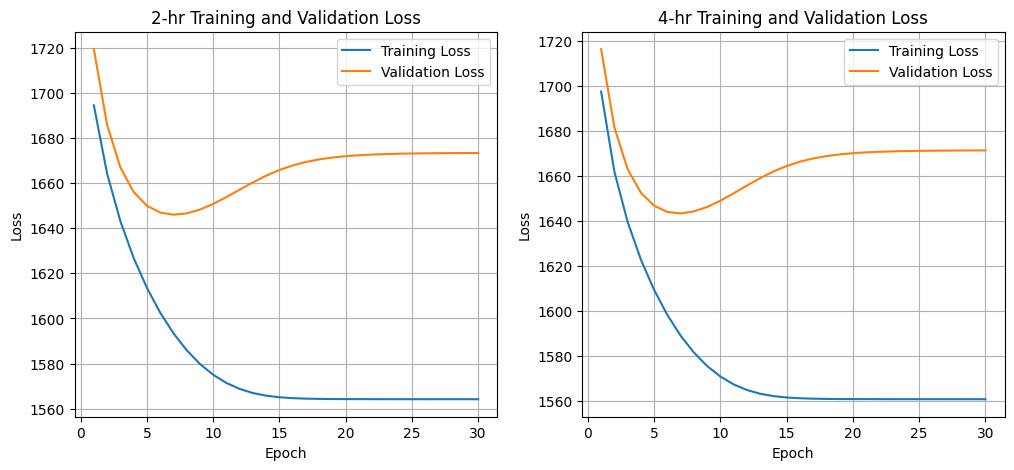

In [49]:
# plot the 2-hr and 4-hr
# get axis parameters
num_epochs = len(two_history.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# plot two_hour
plt.subplot(1,2,1)
plt.plot(epochs, two_history.history["loss"], label="Training Loss")
plt.plot(epochs, two_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-hr Training and Validation Loss")
plt.legend()
plt.grid()

# plot four_hour
plt.subplot(1,2,2)
plt.plot(epochs, four_history.history["loss"], label="Training Loss")
plt.plot(epochs, four_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("4-hr Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

### loss and accuracy plots for 2-hr and 4-hr classification

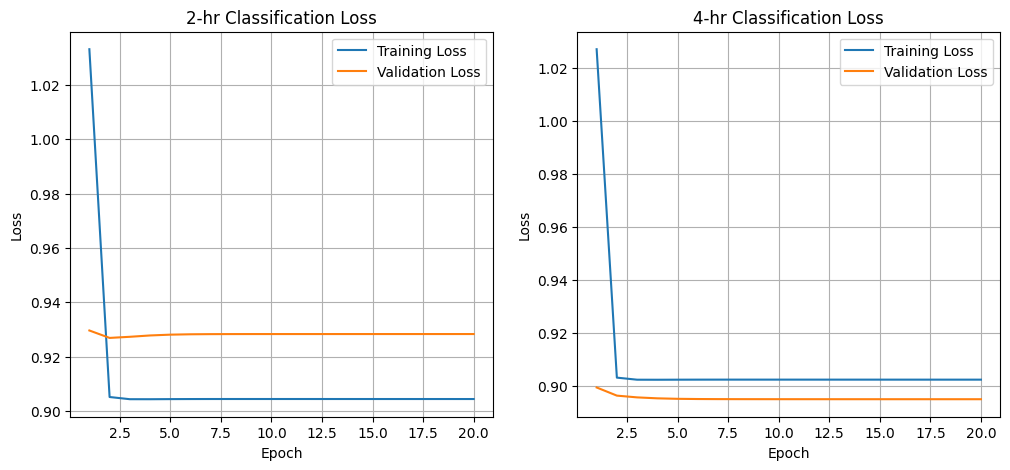

In [52]:
# get the y-axis loss range
num_epochs_cl = len(two_cl_history.history["loss"])
# get the x-axis epoch range
epochs_cl = range(1, num_epochs_cl + 1)

# create figure for plots
plt.figure(figsize=(12,5))

# plot the 2-hour classification
plt.subplot(1,2,1)
plt.plot(epochs_cl, two_cl_history.history["loss"], label="Training Loss")
plt.plot(epochs_cl, two_cl_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-hr Classification Loss")
plt.legend()
plt.grid()

# plot the 4-hour classification
plt.subplot(1,2,2)
plt.plot(epochs_cl, four_cl_history.history["loss"], label="Training Loss")
plt.plot(epochs_cl, four_cl_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("4-hr Classification Loss")
plt.legend()
plt.grid()

plt.show()